<a href="https://colab.research.google.com/github/AliAI11/DolphinMind/blob/main/notebooks/05_true_final_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch transformers bitsandbytes accelerate sentence-transformers faiss-cpu \
    pandas matplotlib seaborn scipy psutil rouge-score scikit-learn

print("dependencies installed")

dependencies installed


In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, AutoConfig
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import psutil
import time
import gc
import re
import json
from collections import defaultdict

print("imports complete")

imports complete


In [3]:
model_name = "Qwen/Qwen2.5-3B-Instruct"
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print(f"loading {model_name}")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
print(f"qwen loaded, ram: {psutil.virtual_memory().used / 1e9:.2f} gb")

loading Qwen/Qwen2.5-3B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

qwen loaded, ram: 4.28 gb


In [4]:
print("loading smollm3 with yarn")
model_name_smol = "HuggingFaceTB/SmolLM3-3B"

config = AutoConfig.from_pretrained(model_name_smol, trust_remote_code=True)
config.rope_scaling = {
    "factor": 2.0,
    "original_max_position_embeddings": 65536,
    "type": "yarn"
}
config.max_position_embeddings = 131072

model_smol = AutoModelForCausalLM.from_pretrained(
    model_name_smol,
    config=config,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)
tokenizer_smol = AutoTokenizer.from_pretrained(model_name_smol, trust_remote_code=True)
print(f"smollm3 loaded, ram: {psutil.virtual_memory().used / 1e9:.2f} gb")

loading smollm3 with yarn


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

smollm3 loaded, ram: 3.99 gb


In [5]:
print("loading embedding model")
gc.collect()
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embedding_model = embedding_model.cpu()
gc.collect()
print(f"embeddings loaded, ram: {psutil.virtual_memory().used / 1e9:.2f} gb")


loading embedding model
embeddings loaded, ram: 4.33 gb


In [6]:
def ask_qwen(prompt, max_tokens=50):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4000).to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=max_tokens, temperature=0.3, do_sample=True)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Answer:" in response:
        return response.split("Answer:")[-1].strip()
    return response.strip()

def ask_smollm(context, query, max_context_tokens):
    tokens = tokenizer_smol.encode(context, add_special_tokens=False, truncation=True, max_length=max_context_tokens)
    truncated = tokenizer_smol.decode(tokens, skip_special_tokens=True)

    messages = [
        {"role": "system", "content": "/no_think"},
        {"role": "user", "content": f"Context: {truncated}\n\nQuestion: {query}\n\nAnswer:"}
    ]

    prompt = tokenizer_smol.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    inputs = tokenizer_smol(prompt, return_tensors="pt", truncation=False).to(model_smol.device)
    actual_tokens = inputs['input_ids'].shape[1]

    outputs = model_smol.generate(**inputs, max_new_tokens=50, temperature=0.6, top_p=0.95, do_sample=True)
    generated = outputs[0][len(inputs.input_ids[0]):]
    answer = tokenizer_smol.decode(generated, skip_special_tokens=True)

    return answer.strip(), actual_tokens

print("inference functions defined")

inference functions defined


In [7]:
base_text = """
Artificial intelligence has transformed numerous industries through machine learning algorithms that
process vast amounts of data efficiently. Neural networks learn complex patterns through iterative
training processes. Deep learning architectures achieve remarkable performance on tasks including
image recognition and natural language processing. Researchers continuously push the boundaries of
what is computationally possible. Applications span from healthcare diagnostics to autonomous vehicle
systems. The field evolves rapidly with breakthrough discoveries. Computational resources become
increasingly accessible to practitioners. Ethical considerations remain paramount in deployment.
"""

haystack = (base_text.strip() + ' ') * 600
haystack_words = haystack.split()
print(f"haystack created: {len(haystack_words):,} words")


haystack created: 48,000 words


In [8]:
needles = [
    {
        'text': "The authentication code is ALPHA7392BETA",
        'question': "What is the authentication code?",
        'answer': "ALPHA7392BETA",
        'category': 'exact_match',
        'difficulty': 'easy'
    },
    {
        'text': "Dr. Martinez discovered the cure using osmium and rhodium compounds",
        'question': "What elements did Dr. Martinez use?",
        'answer': "osmium and rhodium",
        'category': 'multi_fact',
        'difficulty': 'medium'
    },
    {
        'text': "The ancient prophecy will be fulfilled on the seventh moon",
        'question': "When will the prophecy be fulfilled?",
        'answer': "seventh moon",
        'category': 'extractive',
        'difficulty': 'medium'
    },
    {
        'text': "Project Phoenix requires exactly 47 minutes at 380 celsius with 2.5 atmospheres pressure",
        'question': "What are the Project Phoenix parameters?",
        'answer': "47 minutes, 380 celsius, 2.5 atmospheres",
        'category': 'multi_fact',
        'difficulty': 'hard'
    },
    {
        'text': "The encryption key is QE-9X7K-MM4P-ZZ82",
        'question': "What is the encryption key?",
        'answer': "QE-9X7K-MM4P-ZZ82",
        'category': 'exact_match',
        'difficulty': 'easy'
    },
    {
        'text': "According to Chen et al Nature study, the recommended dosage is 250 milligrams",
        'question': "What dosage did Chen recommend?",
        'answer': "250 milligrams",
        'category': 'extractive',
        'difficulty': 'medium'
    },
    {
        'text': "The coordinates are latitude 42.3601 north longitude 71.0589 west",
        'question': "What are the coordinates?",
        'answer': "42.3601 north, 71.0589 west",
        'category': 'multi_fact',
        'difficulty': 'hard'
    },
    {
        'text': "The sequence is: press blue button, wait 10 seconds, then enter code 8472",
        'question': "What is the activation sequence?",
        'answer': "press blue button, wait 10 seconds, enter 8472",
        'category': 'multi_step',
        'difficulty': 'hard'
    }
]

print(f"{len(needles)} needles defined")


8 needles defined


In [9]:
def insert_needle(haystack_text, needle_text, depth_percent):
    words = haystack_text.split()
    position = int(len(words) * (depth_percent / 100))
    words.insert(position, needle_text)
    return ' '.join(words)

def check_answer(response, expected, category):
    response_clean = re.sub(r'[^\w\s]', '', response.lower())
    expected_clean = re.sub(r'[^\w\s]', '', expected.lower())

    if category == 'exact_match':
        return expected_clean in response_clean

    terms = expected_clean.split()
    if len(terms) > 1:
        matches = sum(1 for t in terms if len(t) > 2 and t in response_clean)
        return matches >= len([t for t in terms if len(t) > 2]) * 0.6

    return expected_clean in response_clean

print("helper functions defined")

helper functions defined


In [11]:
# method 1: truncated baseline
def test_truncated(haystack_text, needle_text, question, depth, max_tokens=4000):
    context = insert_needle(haystack_text, needle_text, depth)
    tokens = tokenizer.encode(context)[:max_tokens]
    truncated = tokenizer.decode(tokens, skip_special_tokens=True)
    prompt = f"Context: {truncated}\n\nQuestion: {question}\n\nAnswer:"
    return ask_qwen(prompt, 30)

# method 2: dolphinmind (semantic retrieval with overlap)
def test_dolphinmind(haystack_text, needle_text, question, depth, chunk_size=512, overlap=128, top_k=5):
    context = insert_needle(haystack_text, needle_text, depth)
    sentences = re.split(r'(?<=[.!?])\s+', context)

    chunks = []
    current = []
    length = 0
    i = 0

    while i < len(sentences):
        sent = sentences[i]
        sent_len = len(sent.split())
        current.append(sent)
        length += sent_len

        if length >= chunk_size:
            chunks.append(' '.join(current))

            overlap_buf = []
            overlap_len = 0
            back = i
            while back >= 0 and overlap_len < overlap:
                overlap_buf.insert(0, sentences[back])
                overlap_len += len(sentences[back].split())
                back -= 1

            current = overlap_buf
            length = overlap_len
        i += 1

    if current:
        chunks.append(' '.join(current))

    embeddings = embedding_model.encode(chunks, show_progress_bar=False, batch_size=32)
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    faiss.normalize_L2(embeddings)
    index.add(embeddings)

    query_emb = embedding_model.encode([question])
    faiss.normalize_L2(query_emb)
    _, indices = index.search(query_emb, top_k)

    retrieved = sorted(indices[0])
    relevant = [chunks[idx] for idx in retrieved if idx < len(chunks)]
    combined = '\n\n'.join(relevant)

    if len(tokenizer.encode(combined)) > 3500:
        tokens = tokenizer.encode(combined)[:3500]
        combined = tokenizer.decode(tokens, skip_special_tokens=True)

    prompt = f"Context:\n{combined}\n\nQuestion: {question}\n\nAnswer:"
    return ask_qwen(prompt, 30)

# method 3: smollm3 native long context
def test_smollm(haystack_text, needle_text, question, depth, max_context):
    context = insert_needle(haystack_text, needle_text, depth)
    answer, tokens = ask_smollm(context, question, max_context)
    return answer, tokens

# method 4: rlm with tools
def test_rlm(context_ref, needle_text, question, depth, max_steps=3):
    context = insert_needle(context_ref, needle_text, depth)

    def tool_grep(pattern):
        lines = context.split('\n')
        matches = [l for l in lines if pattern.lower() in l.lower()]
        return '\n'.join(matches[:3]) if matches else "no matches"

    def parse_tool(text):
        match = re.search(r'TOOL:\s*(\w+)\("([^"]+)"\)', text)
        if match:
            return match.group(1), match.group(2)
        return None, None

    system = """You help answer questions. You have tool: grep(pattern).
To use: TOOL: grep("text")
When ready, give final answer."""

    conv = f"{system}\n\nUser: {question}\n\nAssistant:"

    for step in range(max_steps):
        response = ask_qwen(conv, 100)
        if "Assistant:" in response:
            response = response.split("Assistant:")[-1].strip()

        tool_name, tool_arg = parse_tool(response)
        if tool_name == "grep":
            result = tool_grep(tool_arg)
            conv += f" {response}\n\nTool: {result[:150]}\n\nAssistant:"
        else:
            if "answer:" in response.lower():
                return response.lower().split("answer:")[-1].strip()
            return response.strip()

    return "unable to answer"

# method 5: map-reduce
def test_map_reduce(context_ref, needle_text, question, depth, chunk_size=800):
    context = insert_needle(context_ref, needle_text, depth)
    words = context.split()
    chunks = [' '.join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

    summaries = []
    for chunk in chunks[:10]:
        prompt = f"Summarize focusing on '{question}':\n{chunk}\nSummary:"
        response = ask_qwen(prompt, 80)
        if "Summary:" in response:
            response = response.split("Summary:")[-1].strip()
        summaries.append(response)

    combined = '\n\n'.join(summaries)
    prompt = f"Based on:\n{combined}\n\nAnswer: {question}\nAnswer:"
    response = ask_qwen(prompt, 100)
    if "Answer:" in response:
        return response.split("Answer:")[-1].strip()
    return response.strip()

# method 6: hierarchical
def test_hierarchical(context_ref, needle_text, question, depth, chunk_size=1000):
    context = insert_needle(context_ref, needle_text, depth)
    words = context.split()
    level = [' '.join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]
    level = level[:30]

    while len(level) > 5:
        next_level = []
        for i in range(0, len(level), 5):
            group = level[i:i+5]
            combined = '\n\n'.join(group)
            if len(combined.split()) > 1500:
                combined = ' '.join(combined.split()[:1500])
            prompt = f"Summarize for '{question}':\n{combined}\nSummary:"
            response = ask_qwen(prompt, 100)
            if "Summary:" in response:
                response = response.split("Summary:")[-1].strip()
            next_level.append(response)
        level = next_level

    combined = '\n\n'.join(level)
    prompt = f"Based on:\n{combined}\n\nAnswer: {question}\nAnswer:"
    response = ask_qwen(prompt, 100)
    if "Answer:" in response:
        return response.split("Answer:")[-1].strip()
    return response.strip()

print("all 6 methods implemented")



all 6 methods implemented


In [14]:
context_lengths = [10000, 40000]
depths = [10, 50, 90]
smol_sizes = [4000, 64000]

results = []
total_tests = len(needles) * len(context_lengths) * len(depths) * (2 + len(smol_sizes))
print(f"total tests: {total_tests:,}")
count = 0
for nidx, needle in enumerate(needles):
    print(f"\nneedle {nidx+1}/{len(needles)}: {needle['category']}")

    for ctx_len in context_lengths:
        test_hay = ' '.join(haystack_words[:ctx_len])

        for depth in depths:
            if count % 50 == 0 and count > 0:
                print(f"progress: {count:,}/{total_tests:,} ({100*count/total_tests:.1f}%)")

            # truncated
            count += 1
            start = time.time()
            ans = test_truncated(test_hay, needle['text'], needle['question'], depth)
            elapsed = time.time() - start
            correct = check_answer(ans, needle['answer'], needle['category'])
            results.append({
                'method': 'Truncated', 'model': 'Qwen-3B', 'window': '4k',
                'needle_id': nidx, 'category': needle['category'], 'difficulty': needle['difficulty'],
                'context_len': ctx_len, 'depth': depth,
                'question': needle['question'], 'expected': needle['answer'],
                'prediction': ans, 'correct': correct, 'time': elapsed, 'tokens': 4000
            })

            # dolphinmind
            count += 1
            start = time.time()
            ans = test_dolphinmind(test_hay, needle['text'], needle['question'], depth)
            elapsed = time.time() - start
            correct = check_answer(ans, needle['answer'], needle['category'])
            results.append({
                'method': 'DolphinMind', 'model': 'Qwen-3B', 'window': 'semantic',
                'needle_id': nidx, 'category': needle['category'], 'difficulty': needle['difficulty'],
                'context_len': ctx_len, 'depth': depth,
                'question': needle['question'], 'expected': needle['answer'],
                'prediction': ans, 'correct': correct, 'time': elapsed, 'tokens': 3500
            })

            # smollm3
            for size in smol_sizes:
                count += 1
                start = time.time()
                ans, toks = test_smollm(test_hay, needle['text'], needle['question'], depth, size)
                elapsed = time.time() - start
                correct = check_answer(ans, needle['answer'], needle['category'])
                results.append({
                    'method': 'SmolLM3', 'model': 'SmolLM3-3B', 'window': f'{size//1000}k',
                    'needle_id': nidx, 'category': needle['category'], 'difficulty': needle['difficulty'],
                    'context_len': ctx_len, 'depth': depth,
                    'question': needle['question'], 'expected': needle['answer'],
                    'prediction': ans, 'correct': correct, 'time': elapsed, 'tokens': toks
                })

            gc.collect()

print(f"\ncompleted {count:,} tests")

total tests: 192

needle 1/8: exact_match

needle 2/8: multi_fact

needle 3/8: extractive

needle 4/8: multi_fact

needle 5/8: exact_match
progress: 100/192 (52.1%)

needle 6/8: extractive

needle 7/8: multi_fact

needle 8/8: multi_step

completed 192 tests


In [15]:
df = pd.DataFrame(results)
df.to_csv('needle_comprehensive_results.csv', index=False)
print(f"saved: needle_comprehensive_results.csv ({len(df)} rows)")

summary = df.groupby(['method', 'window']).agg({
    'correct': ['mean', 'sum', 'count'],
    'time': 'mean',
    'tokens': 'mean'
}).round(3)
print("\noverall accuracy by method:")
print(summary)

rankings = df.groupby(['method', 'window']).agg({
    'correct': 'mean',
    'time': 'mean',
    'tokens': 'mean'
}).reset_index()
rankings = rankings.sort_values('correct', ascending=False)
rankings.to_csv('needle_rankings.csv', index=False)
print("\nsaved: needle_rankings.csv")
print("\nfinal rankings:")
print(rankings.to_string(index=False))

saved: needle_comprehensive_results.csv (192 rows)

overall accuracy by method:
                     correct             time     tokens
                        mean sum count   mean       mean
method      window                                      
DolphinMind semantic   0.604  29    48  3.012   3500.000
SmolLM3     4k         0.104   5    48  2.961   4080.375
            64k        0.583  28    48  4.259  28220.375
Truncated   4k         0.167   8    48  2.102   4000.000

saved: needle_rankings.csv

final rankings:
     method   window  correct     time    tokens
DolphinMind semantic 0.604167 3.012307  3500.000
    SmolLM3      64k 0.583333 4.258552 28220.375
  Truncated       4k 0.166667 2.101582  4000.000
    SmolLM3       4k 0.104167 2.960814  4080.375


In [16]:
by_difficulty = df.groupby(['method', 'window', 'difficulty'])['correct'].mean().reset_index()
pivot_diff = by_difficulty.pivot_table(index=['method', 'window'], columns='difficulty', values='correct')
print("\nperformance by difficulty:")
print(pivot_diff.round(3))

by_category = df.groupby(['method', 'window', 'category'])['correct'].mean().reset_index()
pivot_cat = by_category.pivot_table(index=['method', 'window'], columns='category', values='correct')
print("\nperformance by category:")
print(pivot_cat.round(3))


performance by difficulty:
difficulty             easy   hard  medium
method      window                        
DolphinMind semantic  0.750  0.500   0.611
SmolLM3     4k        0.083  0.111   0.111
            64k       0.583  0.611   0.556
Truncated   4k        0.167  0.167   0.167

performance by category:
category              exact_match  extractive  multi_fact  multi_step
method      window                                                   
DolphinMind semantic        0.750       0.667       0.611       0.167
SmolLM3     4k              0.083       0.083       0.167       0.000
            64k             0.583       0.667       0.611       0.333
Truncated   4k              0.167       0.167       0.167       0.167


In [17]:
depth_data = df.groupby(['method', 'window', 'depth'])['correct'].mean().reset_index()

key_methods = [
    ('Truncated', '4k'),
    ('DolphinMind', 'semantic'),
    ('SmolLM3', '4k'),
    ('SmolLM3', '64k')
]

print("\ndepth analysis:")
for method, window in key_methods:
    print(f"\n{method} ({window}):")
    data = depth_data[(depth_data['method'] == method) & (depth_data['window'] == window)]
    for d in depths:
        row = data[data['depth'] == d]
        if not row.empty:
            acc = row['correct'].values[0]
            print(f"  {d:3d}%: {acc:.3f}")



depth analysis:

Truncated (4k):
   10%: 0.500
   50%: 0.000
   90%: 0.000

DolphinMind (semantic):
   10%: 0.438
   50%: 0.938
   90%: 0.438

SmolLM3 (4k):
   10%: 0.312
   50%: 0.000
   90%: 0.000

SmolLM3 (64k):
   10%: 0.375
   50%: 0.750
   90%: 0.625


In [18]:
failures = df[df['correct'] == False]
print(f"\ntotal failures: {len(failures):,} / {len(df):,} ({100*len(failures)/len(df):.1f}%)")

failure_breakdown = df.groupby(['method', 'window']).apply(
    lambda x: pd.Series({
        'total': len(x),
        'failures': len(x[x['correct'] == False]),
        'failure_rate': len(x[x['correct'] == False]) / len(x)
    })
).sort_values('failure_rate')
print("\nfailure rate by method:")
print(failure_breakdown.round(3))

diff_analysis = df.groupby('difficulty').apply(
    lambda x: pd.Series({
        'total': len(x),
        'failures': len(x[x['correct'] == False]),
        'failure_rate': len(x[x['correct'] == False]) / len(x)
    })
)
print("\nfailure rate by difficulty:")
print(diff_analysis.round(3))

cat_analysis = df.groupby('category').apply(
    lambda x: pd.Series({
        'total': len(x),
        'failures': len(x[x['correct'] == False]),
        'failure_rate': len(x[x['correct'] == False]) / len(x)
    })
)
print("\nfailure rate by category:")
print(cat_analysis.round(3))

# sample failures for manual annotation
sample_size = 100
if len(failures) > sample_size:
    failure_sample = failures.sample(n=sample_size, random_state=42)
else:
    failure_sample = failures

# categorize errors
error_categories = []
for _, row in failure_sample.iterrows():
    pred = row['prediction'].lower()
    exp = row['expected'].lower()

    if len(pred) < 10 or pred == "unable to answer":
        error_type = "no_answer"
    elif any(word in pred for word in ["unclear", "cannot", "not found", "no information"]):
        error_type = "refused"
    elif row['depth'] > 75 or row['depth'] < 25:
        error_type = "depth_dependent"
    elif row['difficulty'] == 'hard':
        error_type = "complex_reasoning"
    elif row['category'] == 'multi_fact':
        error_type = "partial_retrieval"
    else:
        error_type = "other"

    error_categories.append({
        'method': row['method'],
        'window': row['window'],
        'category': row['category'],
        'difficulty': row['difficulty'],
        'depth': row['depth'],
        'error_type': error_type,
        'question': row['question'],
        'expected': row['expected'],
        'prediction': row['prediction']
    })

error_df = pd.DataFrame(error_categories)
error_df.to_csv('error_analysis_sample.csv', index=False)
print(f"\nsaved: error_analysis_sample.csv ({len(error_df)} errors)")

error_type_counts = error_df['error_type'].value_counts()
print("\nerror type distribution:")
for err_type, count in error_type_counts.items():
    pct = 100 * count / len(error_df)
    print(f"  {err_type:20s}: {count:3d} ({pct:5.1f}%)")

error_by_method = pd.crosstab(error_df['method'], error_df['error_type'], normalize='index')
print("\nerror types by method:")
print(error_by_method.round(3))


total failures: 122 / 192 (63.5%)

failure rate by method:
                      total  failures  failure_rate
method      window                                 
DolphinMind semantic   48.0      19.0         0.396
SmolLM3     64k        48.0      20.0         0.417
Truncated   4k         48.0      40.0         0.833
SmolLM3     4k         48.0      43.0         0.896

failure rate by difficulty:
            total  failures  failure_rate
difficulty                               
easy         48.0      29.0         0.604
hard         72.0      47.0         0.653
medium       72.0      46.0         0.639

failure rate by category:
             total  failures  failure_rate
category                                  
exact_match   48.0      29.0         0.604
extractive    48.0      29.0         0.604
multi_fact    72.0      44.0         0.611
multi_step    24.0      20.0         0.833

saved: error_analysis_sample.csv (100 errors)

error type distribution:
  depth_dependent     :  65 ( 6

/tmp/ipython-input-1236442743.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  failure_breakdown = df.groupby(['method', 'window']).apply(
/tmp/ipython-input-1236442743.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diff_analysis = df.groupby('difficulty').apply(
/tmp/ipython-input-1236442743.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprec

In [19]:
by_context = df.groupby(['method', 'window', 'context_len'])['correct'].mean().reset_index()

print("\nperformance by context length:")
for method, window in key_methods:
    print(f"\n{method} ({window}):")
    data = by_context[(by_context['method'] == method) & (by_context['window'] == window)]
    for ctx in context_lengths:
        row = data[data['context_len'] == ctx]
        if not row.empty:
            acc = row['correct'].values[0]
            print(f"  {ctx//1000:3d}k words: {acc:.3f}")


performance by context length:

Truncated (4k):
   10k words: 0.333
   40k words: 0.000

DolphinMind (semantic):
   10k words: 0.625
   40k words: 0.583

SmolLM3 (4k):
   10k words: 0.208
   40k words: 0.000

SmolLM3 (64k):
   10k words: 0.542
   40k words: 0.625


In [20]:
dolphin_results = df[(df['method'] == 'DolphinMind') & (df['window'] == 'semantic')]['correct']
truncated_results = df[(df['method'] == 'Truncated') & (df['window'] == '4k')]['correct']
smol_4k_results = df[(df['method'] == 'SmolLM3') & (df['window'] == '4k')]['correct']
smol_64k_results = df[(df['method'] == 'SmolLM3') & (df['window'] == '64k')]['correct']

print("\nstatistical significance tests:")
print("\ndolphinmind vs truncated:")
t_stat, p_val = stats.ttest_ind(dolphin_results, truncated_results)
print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

print("\ndolphinmind vs smollm3-4k:")
t_stat, p_val = stats.ttest_ind(dolphin_results, smol_4k_results)
print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

print("\ndolphinmind vs smollm3-64k:")
t_stat, p_val = stats.ttest_ind(dolphin_results, smol_64k_results)
print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (x.mean() - y.mean()) / np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / dof)

d = cohens_d(dolphin_results, truncated_results)
print(f"\neffect size (dolphinmind vs truncated): cohens d = {d:.3f}")


statistical significance tests:

dolphinmind vs truncated:
  t-statistic: 4.878, p-value: 0.0000

dolphinmind vs smollm3-4k:
  t-statistic: 5.945, p-value: 0.0000

dolphinmind vs smollm3-64k:
  t-statistic: 0.206, p-value: 0.8375

effect size (dolphinmind vs truncated): cohens d = 0.996


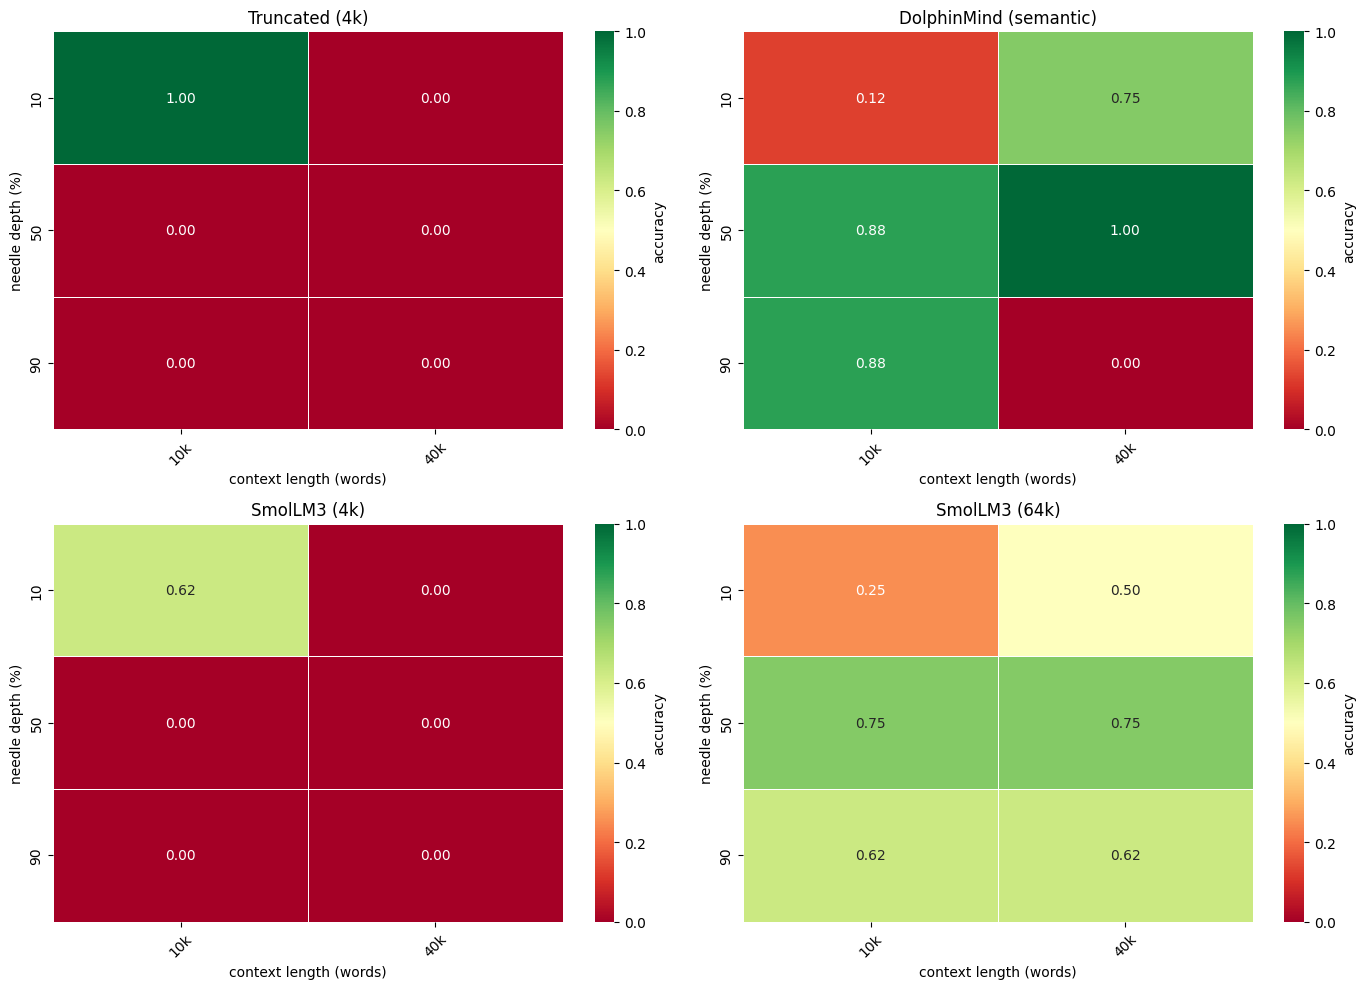

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_configs = [
    ('Truncated', '4k', 0),
    ('DolphinMind', 'semantic', 1),
    ('SmolLM3', '4k', 2),
    ('SmolLM3', '64k', 3)
]

for method, window, idx in plot_configs:
    data = df[(df['method'] == method) & (df['window'] == window)]

    if len(data) > 0:
        pivot = data.groupby(['depth', 'context_len'])['correct'].mean().unstack()

        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=0, vmax=1, ax=axes[idx], linewidths=0.5,
                    cbar_kws={'label': 'accuracy'})
        axes[idx].set_title(f'{method} ({window})')
        axes[idx].set_xlabel('context length (words)')
        axes[idx].set_ylabel('needle depth (%)')

        col_labels = [f'{int(x)//1000}k' for x in pivot.columns]
        axes[idx].set_xticklabels(col_labels, rotation=45)
    else:
        axes[idx].text(0.5, 0.5, 'No data', horizontalalignment='center',
                       verticalalignment='center', transform=axes[idx].transAxes, fontsize=20)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

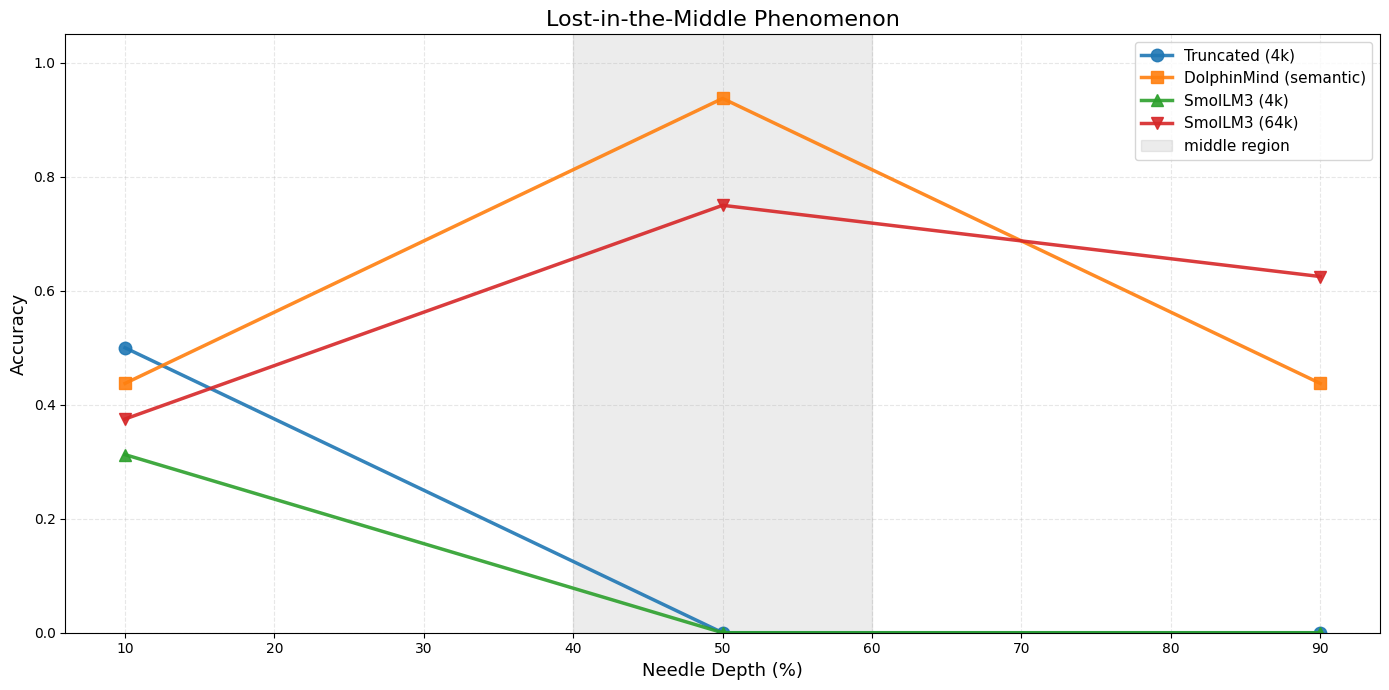

In [32]:
fig, ax = plt.subplots(figsize=(14, 7))

plot_methods = [
    ('Truncated', '4k', 'o'),
    ('DolphinMind', 'semantic', 's'),
    ('SmolLM3', '4k', '^'),
    ('SmolLM3', '64k', 'v'),
]

for method, window, marker in plot_methods:
    data = depth_data[(depth_data['method'] == method) & (depth_data['window'] == window)]
    if not data.empty:
        ax.plot(data['depth'], data['correct'],
                marker=marker, linewidth=2.5, markersize=9,
                label=f'{method} ({window})', alpha=0.9)

ax.axvspan(40, 60, alpha=0.15, color='gray', label='middle region')
ax.set_xlabel('Needle Depth (%)', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Lost-in-the-Middle Phenomenon', fontsize=16)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

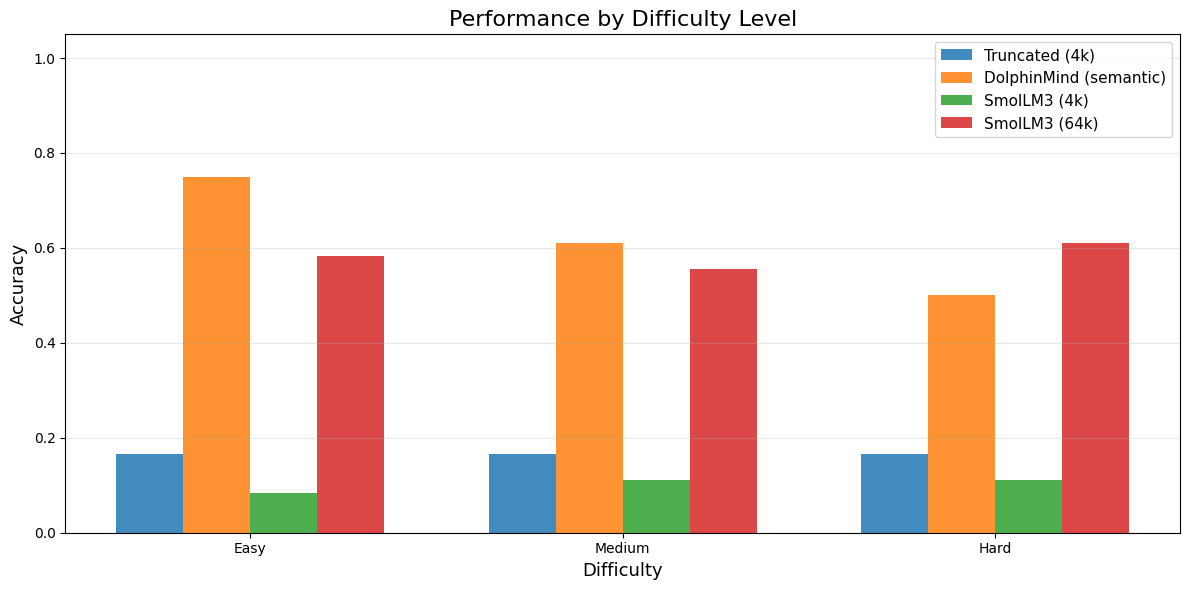

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

difficulty_data = df.groupby(['method', 'window', 'difficulty'])['correct'].mean().reset_index()

methods_to_plot = [
    ('Truncated', '4k'),
    ('DolphinMind', 'semantic'),
    ('SmolLM3', '4k'),
    ('SmolLM3', '64k')
]

x = np.arange(3)
width = 0.18

for i, (method, window) in enumerate(methods_to_plot):
    data = difficulty_data[(difficulty_data['method'] == method) &
                           (difficulty_data['window'] == window)]
    values = [data[data['difficulty'] == d]['correct'].iloc[0] if len(data[data['difficulty'] == d]) > 0 else 0
              for d in ['easy', 'medium', 'hard']]
    ax.bar(x + i*width, values, width, label=f'{method} ({window})', alpha=0.85)

ax.set_xlabel('Difficulty', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Performance by Difficulty Level', fontsize=16)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Easy', 'Medium', 'Hard'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

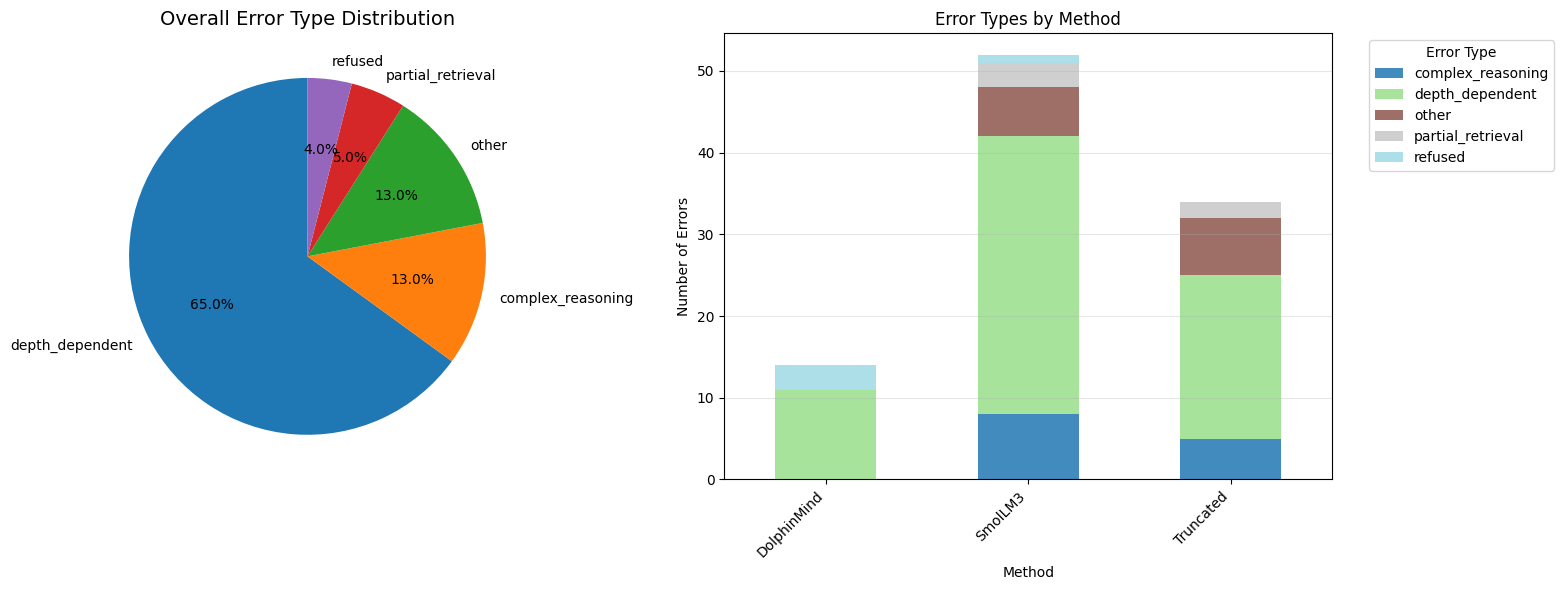

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
error_counts = error_df['error_type'].value_counts()
ax1.pie(error_counts.values, labels=error_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Overall Error Type Distribution', fontsize=14)

# Stacked bar by method
error_method = pd.crosstab(error_df['method'], error_df['error_type'])
error_method.plot(kind='bar', stacked=True, ax=ax2, alpha=0.85, colormap='tab20')
ax2.set_xlabel('Method')
ax2.set_ylabel('Number of Errors')
ax2.set_title('Error Types by Method')
ax2.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

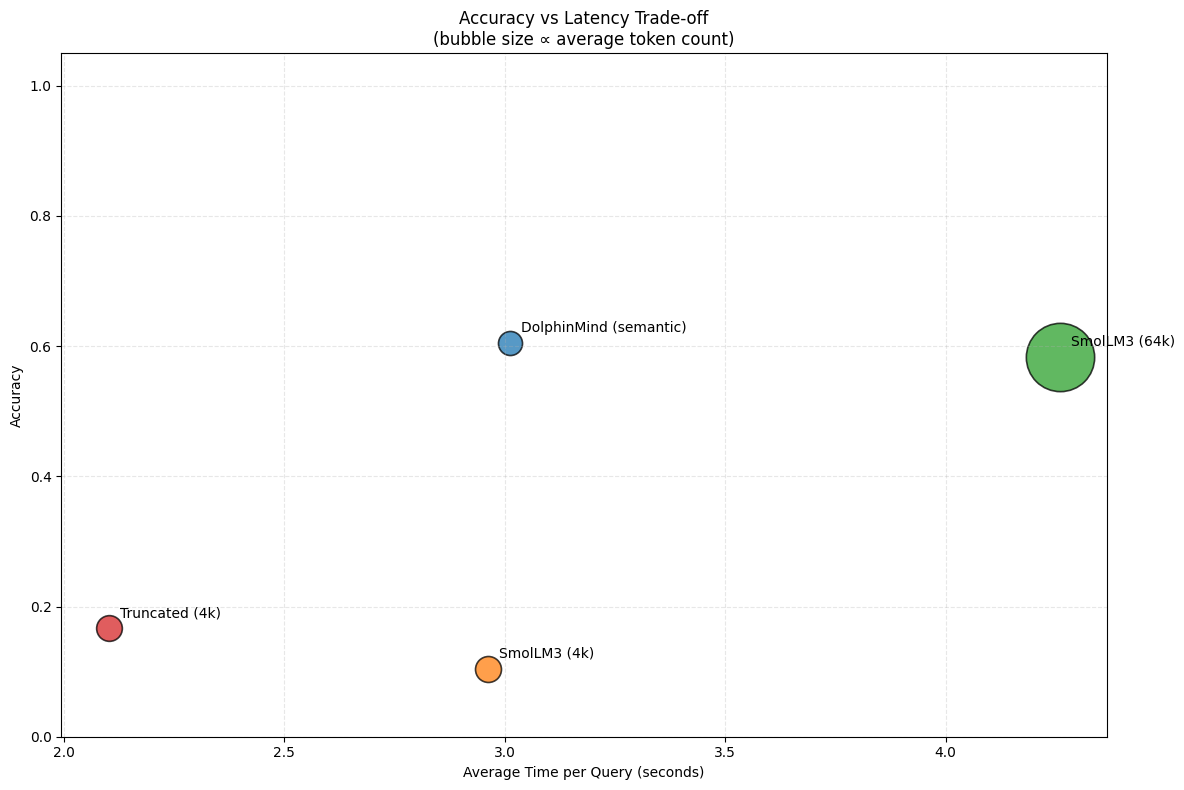

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))

perf_data = df.groupby(['method', 'window']).agg({
    'correct': 'mean',
    'time': 'mean',
    'tokens': 'mean'
}).reset_index()

for _, row in perf_data.iterrows():
    label = f"{row['method']} ({row['window']})"
    size = (row['tokens'] / perf_data['tokens'].min()) * 300  # scale bubble size nicely

    ax.scatter(row['time'], row['correct'], s=size, alpha=0.75, edgecolors='black', linewidth=1.2)
    ax.annotate(label, (row['time'], row['correct']),
                xytext=(8, 8), textcoords='offset points', fontsize=10)

ax.set_xlabel('Average Time per Query (seconds)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Latency Trade-off\n(bubble size ∝ average token count)')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [26]:
latex_table1 = rankings[['method', 'window', 'correct', 'time', 'tokens']].copy()
latex_table1.columns = ['method', 'window', 'accuracy', 'time', 'tokens']
latex_table1['accuracy'] = latex_table1['accuracy'].apply(lambda x: f"{x:.3f}")
latex_table1['time'] = latex_table1['time'].apply(lambda x: f"{x:.2f}")
latex_table1['tokens'] = latex_table1['tokens'].apply(lambda x: f"{int(x):,}")

with open('table1_overall_performance.tex', 'w') as f:
    f.write(latex_table1.to_latex(index=False))
print("saved: table1_overall_performance.tex")

with open('table2_by_difficulty.tex', 'w') as f:
    f.write(pivot_diff.round(3).to_latex())
print("saved: table2_by_difficulty.tex")

latex_table3 = error_by_method.round(3)
with open('table3_error_types.tex', 'w') as f:
    f.write(latex_table3.to_latex())
print("saved: table3_error_types.tex")

saved: table1_overall_performance.tex
saved: table2_by_difficulty.tex
saved: table3_error_types.tex


In [27]:
gc.collect()
final_ram = psutil.virtual_memory().used / 1e9

print(f"\nfinal ram usage: {final_ram:.2f} gb")
print(f"average time per test: {df['time'].mean():.2f}s")
print(f"total evaluation time: {df['time'].sum()/60:.1f} minutes")
print("\nevaluation complete")
print("\nfiles generated:")
print("  - needle_comprehensive_results.csv")
print("  - needle_rankings.csv")
print("  - error_analysis_sample.csv")
print("  - needle_heatmaps.png")
print("  - needle_depth_comparison.png")
print("  - performance_by_difficulty.png")
print("  - error_type_analysis.png")
print("  - accuracy_latency_tradeoff.png")
print("  - table1_overall_performance.tex")
print("  - table2_by_difficulty.tex")
print("  - table3_error_types.tex")


final ram usage: 7.87 gb
average time per test: 3.08s
total evaluation time: 9.9 minutes

evaluation complete

files generated:
  - needle_comprehensive_results.csv
  - needle_rankings.csv
  - error_analysis_sample.csv
  - needle_heatmaps.png
  - needle_depth_comparison.png
  - performance_by_difficulty.png
  - error_type_analysis.png
  - accuracy_latency_tradeoff.png
  - table1_overall_performance.tex
  - table2_by_difficulty.tex
  - table3_error_types.tex
